In [41]:
import pandas as pd

prediction_all = pd.read_csv("../Data/Merged/Prediction_all.csv")
prediction_with_sofr = pd.read_csv("../Data/Merged/Prediction_all_with_sofr.csv")

print("\n=== Prediction_all_with_sofr.csv ===")
print(f"Shape: {prediction_with_sofr.shape}")
display(prediction_with_sofr.head())


=== Prediction_all_with_sofr.csv ===
Shape: (2484, 22)


,decision_date,observed_day_pst,kalshi_C25,kalshi_C50+,kalshi_H0,kalshi_H25,kalshi_H50,kalshi_H50+,polymarket_C25,polymarket_C50,...,polymarket_H0,polymarket_H25,polymarket_H25+,polymarket_H50,polymarket_H50+,polymarket_H75,jump_sr1,jump_ois,jump_sr1_portfolio_weights,jump_ois_portfolio_weights
0,2023-02-01,2022-12-15,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.50,0.66,NaN,0.25,NaN,0.15,0.004461,0.003196,"{""SR1:2022-12"": -0.5183620665001569, ""SR1:2023...","{""OIS_2.26667M_3"": -4.046052599695867, ""OIS_3...."
1,2023-02-01,2022-12-16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.08,0.66,NaN,0.25,NaN,0.15,0.004474,0.003082,"{""SR1:2022-12"": -0.5183620665001569, ""SR1:2023...","{""OIS_2.23333M_3"": -4.17657043979944, ""OIS_3.1..."
2,2023-02-01,2022-12-17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.08,0.66,NaN,0.25,NaN,0.15,NaN,NaN,NaN,NaN
3,2023-02-01,2022-12-18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.05,0.66,NaN,0.25,NaN,0.15,NaN,NaN,NaN,NaN
4,2023-02-01,2022-12-19,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.05,0.66,NaN,0.25,NaN,0.15,0.004725,0.003762,"{""SR1:2022-12"": -0.5183620665001569, ""SR1:2023...","{""OIS_2.13333M_3"": -4.4947368393786, ""OIS_3.06..."


In [42]:
import numpy as np
import matplotlib.pyplot as plt

df = prediction_with_sofr.copy()
df["observed_day_pst"] = pd.to_datetime(df["observed_day_pst"])

# BPS mapping for each source
kalshi_map = {
    "kalshi_C50+": -50, "kalshi_C25": -25, "kalshi_H0": 0,
    "kalshi_H25": 25, "kalshi_H50": 50, "kalshi_H50+": 50,
}
poly_map = {
    "polymarket_C75+": -75, "polymarket_C50+": -50, "polymarket_C50": -50,
    "polymarket_C25": -25, "polymarket_H0": 0, "polymarket_H25": 25,
    "polymarket_H25+": 25, "polymarket_H50": 50, "polymarket_H50+": 50,
    "polymarket_H75": 75,
}
# SOFR columns no longer in CSV; using jump_ois as SOFR-derived expected change
# (jump_sr1 and jump_ois are the new column names)

def expected_change(row, col_map):
    total_prob = 0
    weighted = 0
    for col, bps in col_map.items():
        p = row.get(col)
        if pd.notna(p) and p != "":
            p = float(p)
            weighted += p * bps
            total_prob += p
    if total_prob < 0.01:
        return np.nan
    return weighted / total_prob

df["kalshi_expected_bps"] = df.apply(lambda r: expected_change(r, kalshi_map), axis=1)
df["poly_expected_bps"] = df.apply(lambda r: expected_change(r, poly_map), axis=1)
if "jump_ois" in df.columns:
    df["sofr_expected_bps"] = pd.to_numeric(df["jump_ois"], errors="coerce") * 10000
else:
    df["sofr_expected_bps"] = np.nan

# Pick a meeting with good data coverage across all three sources
meetings = df.groupby("decision_date").apply(
    lambda g: g[["kalshi_expected_bps", "poly_expected_bps", "sofr_expected_bps"]].notna().all(axis=1).sum()
).sort_values(ascending=False)
print("Meetings ranked by # of days with all 3 sources:")
print(meetings.head(10))

best_meeting = meetings.index[0]
print(f"\nPlotting: {best_meeting}")



# --- Load EFFR (Fed Funds) Futures and extract meeting-level expected changes ---
import calendar

effr = pd.read_csv("../Data/EFFR_Futures/effr_futures.csv",
                    usecols=["Date_", "Settlement", "LastTrdDate", "DSMnem"])
effr["obs_date"] = pd.to_datetime(effr["Date_"], errors="coerce")
effr["Settlement"] = pd.to_numeric(effr["Settlement"], errors="coerce")
effr = effr.dropna(subset=["obs_date", "Settlement"])
effr["implied_rate"] = (100.0 - effr["Settlement"]) / 100.0

effr["last_trade"] = pd.to_datetime(effr["LastTrdDate"], errors="coerce")
effr = effr.dropna(subset=["last_trade"])
effr["contr_year"] = effr["last_trade"].dt.year
effr["contr_month"] = effr["last_trade"].dt.month
effr["obs_str"] = effr["obs_date"].dt.strftime("%Y-%m-%d")

effr = effr.sort_values("obs_date")
effr = effr.drop_duplicates(subset=["obs_str", "contr_year", "contr_month"], keep="last")

effr_lookup = {}
for _, row in effr.iterrows():
    effr_lookup[(row["obs_str"], row["contr_year"], row["contr_month"])] = row["implied_rate"]

print(f"EFFR lookup built: {len(effr_lookup)} entries")
print(f"  Observation dates: {effr['obs_str'].min()} to {effr['obs_str'].max()}")

df["obs_str"] = df["observed_day_pst"].dt.strftime("%Y-%m-%d")

# CME FedWatch formula with late-month fix:
#   If meeting is in first 2/3 of month (d <= N*2/3): standard formula
#     pre_rate = prev_month contract, post_rate derived from meeting_month contract
#   If meeting is late in month (d > N*2/3): flipped formula
#     pre_rate = meeting_month contract (almost all days are pre-meeting)
#     post_rate = next_month contract (all days are post-meeting)

LATE_MONTH_THRESHOLD = 0.67

all_meeting_dates = sorted(df["decision_date"].unique())

effr_rows = []
diag_missing = {}
for meeting_str in all_meeting_dates:
    meeting_dt = pd.Timestamp(meeting_str)
    m_day = meeting_dt.day
    m_year = meeting_dt.year
    m_month = meeting_dt.month
    days_in_month = calendar.monthrange(m_year, m_month)[1]

    late_month = (m_day / days_in_month) > LATE_MONTH_THRESHOLD

    if late_month:
        # Late-month: meeting_month = pre, next_month = post
        if m_month == 12:
            next_year, next_month = m_year + 1, 1
        else:
            next_year, next_month = m_year, m_month + 1
        need_a = (m_year, m_month)       # meeting month = pre-meeting rate
        need_b = (next_year, next_month)  # next month = post-meeting rate
        method = "late"
    else:
        # Standard: prev_month = pre, meeting_month used to derive post
        if m_month == 1:
            prev_year, prev_month = m_year - 1, 12
        else:
            prev_year, prev_month = m_year, m_month - 1
        need_a = (prev_year, prev_month)  # prev month = pre-meeting rate
        need_b = (m_year, m_month)        # meeting month
        method = "standard"

    obs_strs = df.loc[df["decision_date"] == meeting_str, "obs_str"].sort_values().unique()
    matched = 0
    for obs_s in obs_strs:
        rate_a = effr_lookup.get((obs_s, need_a[0], need_a[1]))
        rate_b = effr_lookup.get((obs_s, need_b[0], need_b[1]))
        if rate_a is None or rate_b is None:
            continue

        if late_month:
            pre_rate = rate_a   # meeting month avg ~ pre-meeting rate
            post_rate = rate_b  # next month = post-meeting rate
        else:
            pre_rate = rate_a   # prev month = pre-meeting rate
            meeting_avg = rate_b
            denom = days_in_month - m_day
            if denom <= 0:
                continue
            post_rate = (meeting_avg * days_in_month - pre_rate * m_day) / denom

        exp_change_bps = (post_rate - pre_rate) * 10000
        effr_rows.append({
            "decision_date": meeting_str,
            "obs_str": obs_s,
            "effr_expected_bps": exp_change_bps,
        })
        matched += 1

    if matched == 0:
        has_a = any(k[1] == need_a[0] and k[2] == need_a[1] for k in effr_lookup)
        has_b = any(k[1] == need_b[0] and k[2] == need_b[1] for k in effr_lookup)
        diag_missing[meeting_str] = f"method={method}, contract_A({'YES' if has_a else 'NO'}), contract_B({'YES' if has_b else 'NO'})"
    else:
        print(f"  {meeting_str} ({method}, day {m_day}/{days_in_month}): {matched} obs")

if diag_missing:
    print(f"\nMeetings with NO EFFR data:")
    for m, reason in diag_missing.items():
        print(f"  {m}: {reason}")

effr_df = pd.DataFrame(effr_rows)
if not effr_df.empty:
    df = df.merge(effr_df, on=["decision_date", "obs_str"], how="left")
else:
    df["effr_expected_bps"] = np.nan

n_effr = df["effr_expected_bps"].notna().sum()
n_meetings_effr = df.loc[df["effr_expected_bps"].notna(), "decision_date"].nunique()
print(f"\nEFFR futures: {n_effr} observations across {n_meetings_effr} meetings")


Meetings ranked by # of days with all 3 sources:
decision_date
2025-12-10    90
2026-01-28    86
2026-03-18    82
2026-04-29    71
2025-10-29    61
2026-06-17    52
2023-09-20    39
2024-11-07    37
2024-09-18    36
2025-03-19    35
dtype: int64

Plotting: 2025-12-10
EFFR lookup built: 35793 entries
  Observation dates: 2020-09-18 to 2026-02-24
  2023-10-31 (late, day 31/31): 29 obs
  2024-07-31 (late, day 31/31): 34 obs
  2024-09-18 (standard, day 18/30): 27 obs
  2024-11-07 (standard, day 7/30): 64 obs
  2025-07-30 (late, day 30/31): 91 obs
  2025-09-17 (standard, day 17/30): 80 obs
  2025-10-29 (late, day 29/31): 91 obs
  2025-12-10 (standard, day 10/31): 85 obs
  2026-01-28 (late, day 28/31): 91 obs
  2026-03-18 (standard, day 18/31): 102 obs
  2026-04-29 (late, day 29/30): 102 obs
  2026-06-17 (standard, day 17/30): 102 obs

Meetings with NO EFFR data:
  2023-02-01: method=standard, contract_A(NO), contract_B(NO)
  2023-03-22: method=late, contract_A(NO), contract_B(NO)
  2023-05-

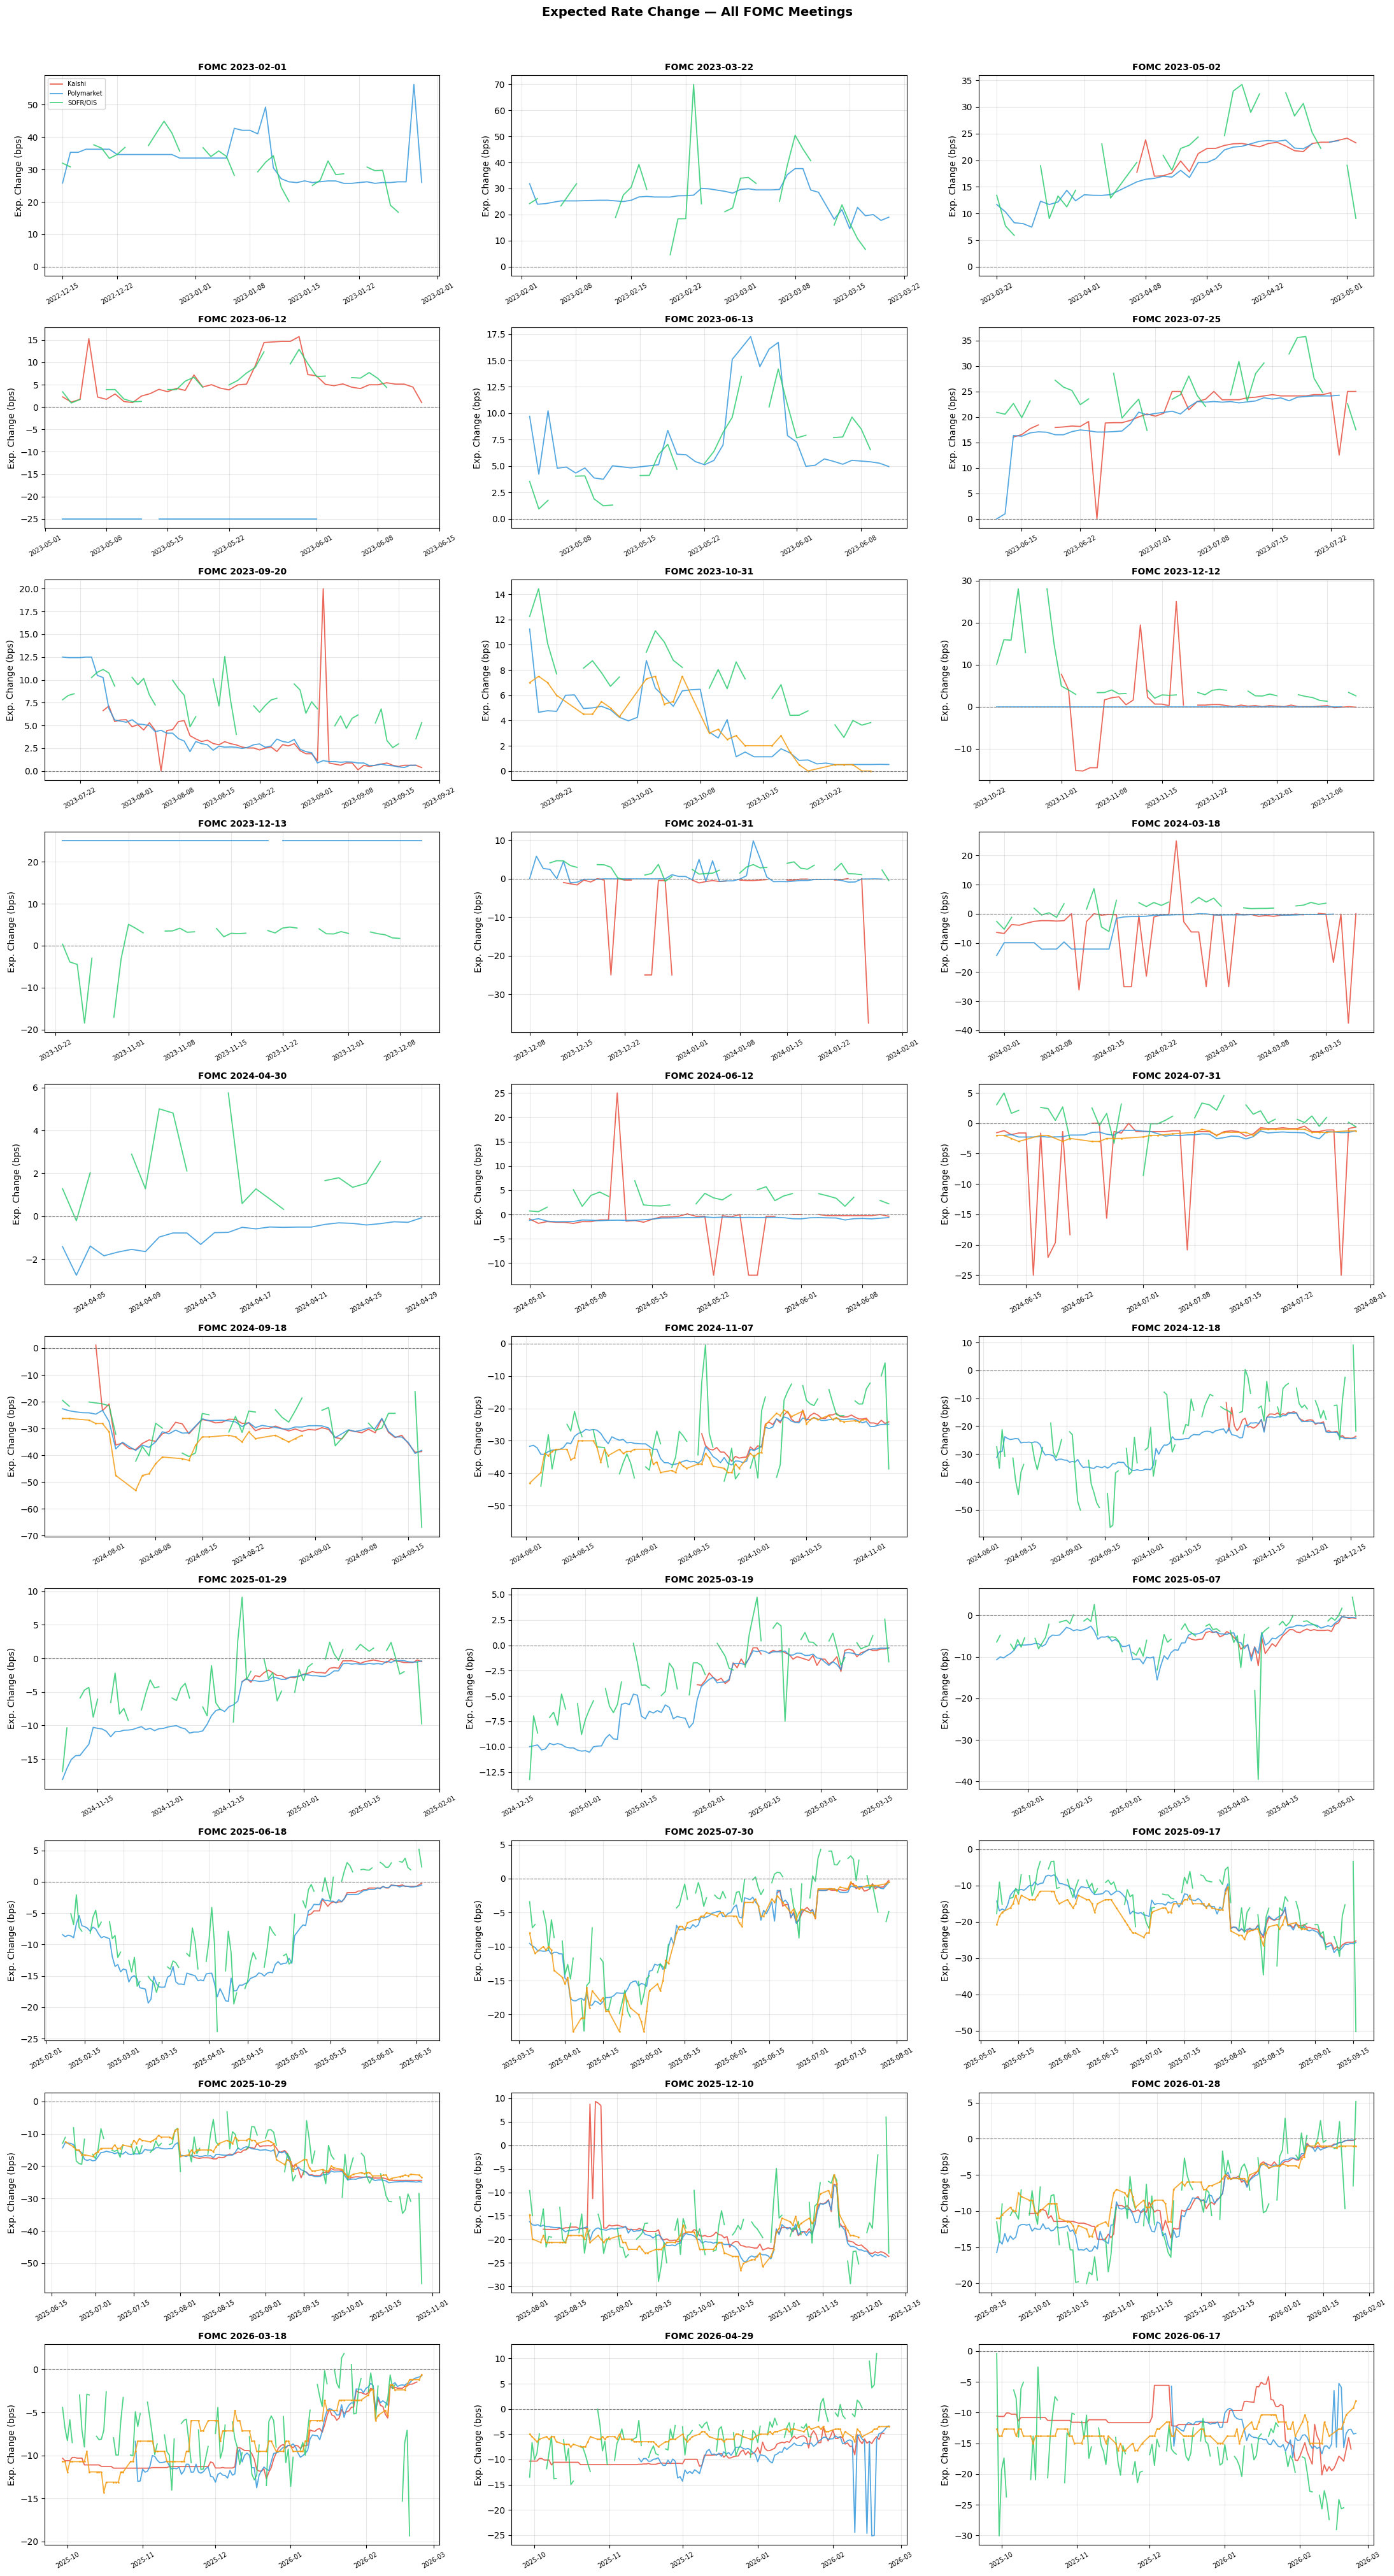

In [43]:
all_meetings = sorted(df["decision_date"].unique())
n = len(all_meetings)
cols = 3
rows_grid = (n + cols - 1) // cols

fig, axes = plt.subplots(rows_grid, cols, figsize=(22, 4 * rows_grid))
axes = axes.flatten()

for i, meeting in enumerate(all_meetings):
    ax = axes[i]
    meeting_df = df[df["decision_date"] == meeting].sort_values("observed_day_pst")

    ax.plot(meeting_df["observed_day_pst"], meeting_df["kalshi_expected_bps"],
            label="Kalshi", color="#e74c3c", linewidth=1.3, alpha=0.85)
    ax.plot(meeting_df["observed_day_pst"], meeting_df["poly_expected_bps"],
            label="Polymarket", color="#3498db", linewidth=1.3, alpha=0.85)
    ax.plot(meeting_df["observed_day_pst"], meeting_df["sofr_expected_bps"],
            label="SOFR/OIS", color="#2ecc71", linewidth=1.3, alpha=0.85)

    effr_mask = meeting_df["effr_expected_bps"].notna()
    if effr_mask.any():
        ax.plot(meeting_df.loc[effr_mask, "observed_day_pst"],
                meeting_df.loc[effr_mask, "effr_expected_bps"],
                label="EFFR Futures", color="#f39c12", linewidth=1.3,
                alpha=0.85, marker=".", markersize=2)

    ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
    ax.set_title(f"FOMC {meeting}", fontsize=10, fontweight="bold")
    ax.set_ylabel("Exp. Change (bps)")
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis="x", rotation=30, labelsize=7)
    if i == 0:
        ax.legend(fontsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Expected Rate Change \u2014 All FOMC Meetings", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


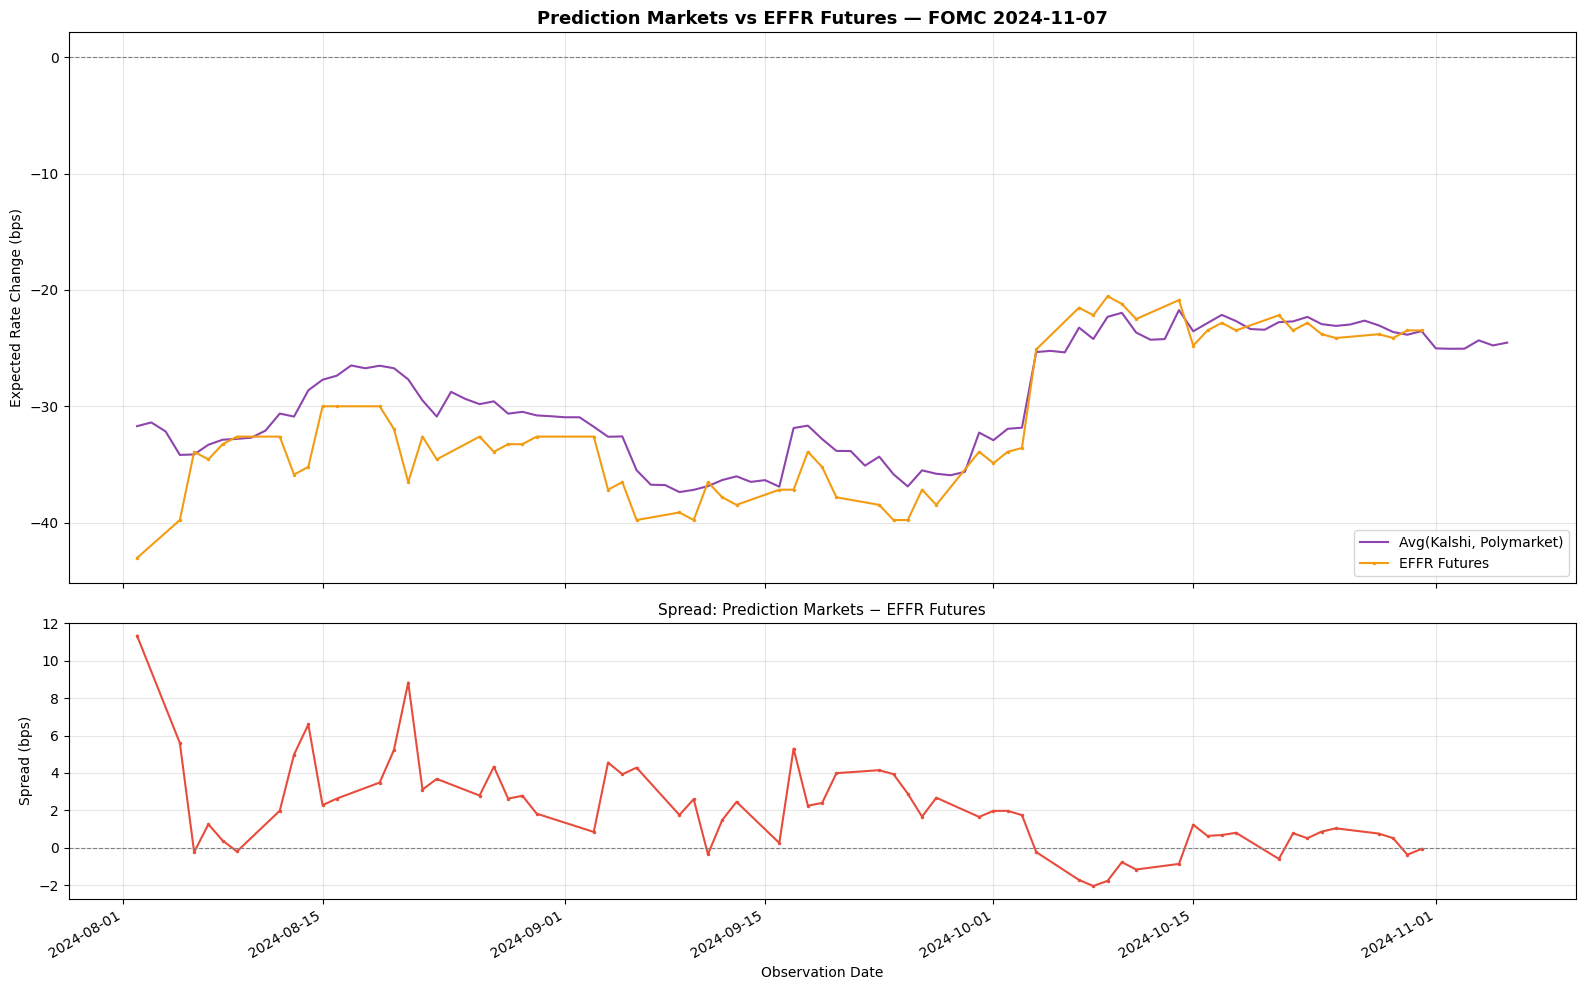

Spread stats (where both available):
  Mean:   2.06 bps
  Std:    2.43 bps
  Min:    -2.04 bps
  Max:    11.33 bps
  N obs:  64


In [44]:
meeting = "2024-11-07"
mdf = df[df["decision_date"] == meeting].sort_values("observed_day_pst").copy()

mdf["predmkt_avg_bps"] = mdf[["kalshi_expected_bps", "poly_expected_bps"]].mean(axis=1)
mdf["spread_bps"] = mdf["predmkt_avg_bps"] - mdf["effr_expected_bps"]

mask = mdf[["predmkt_avg_bps", "effr_expected_bps"]].notna().all(axis=1)
mdf_clean = mdf[mask]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10), sharex=True,
                                gridspec_kw={"height_ratios": [2, 1]})

ax1.plot(mdf["observed_day_pst"], mdf["predmkt_avg_bps"],
         label="Avg(Kalshi, Polymarket)", color="#8e44ad", linewidth=1.5)
effr_mask = mdf["effr_expected_bps"].notna()
ax1.plot(mdf.loc[effr_mask, "observed_day_pst"], mdf.loc[effr_mask, "effr_expected_bps"],
         label="EFFR Futures", color="#f39c12", linewidth=1.5, marker=".", markersize=3)
ax1.axhline(0, color="gray", linestyle="--", linewidth=0.8)
ax1.set_ylabel("Expected Rate Change (bps)")
ax1.set_title(f"Prediction Markets vs EFFR Futures \u2014 FOMC {meeting}", fontsize=13, fontweight="bold")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(mdf_clean["observed_day_pst"], mdf_clean["spread_bps"],
         color="#e74c3c", linewidth=1.5, marker=".", markersize=3)
ax2.axhline(0, color="gray", linestyle="--", linewidth=0.8)
ax2.set_ylabel("Spread (bps)")
ax2.set_xlabel("Observation Date")
ax2.set_title("Spread: Prediction Markets \u2212 EFFR Futures", fontsize=11)
ax2.grid(True, alpha=0.3)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

print(f"Spread stats (where both available):")
print(f"  Mean:   {mdf_clean['spread_bps'].mean():.2f} bps")
print(f"  Std:    {mdf_clean['spread_bps'].std():.2f} bps")
print(f"  Min:    {mdf_clean['spread_bps'].min():.2f} bps")
print(f"  Max:    {mdf_clean['spread_bps'].max():.2f} bps")
print(f"  N obs:  {len(mdf_clean)}")

In [45]:
from statsmodels.tsa.stattools import adfuller
from scipy.optimize import minimize
import warnings
warnings.filterwarnings("ignore")

def ou_analysis(spread: pd.Series, dt: float = 1.0, label: str = ""):
    """
    Full Ornstein-Uhlenbeck analysis à la Avellaneda & Lee.
    
    Estimates parameters via:
      1. AR(1) OLS regression (quick)
      2. Exact MLE (more rigorous)
    Then runs ADF test and computes trading metrics.
    """
    s = spread.dropna().values
    if len(s) < 10:
        return None

    # --- AR(1) OLS: S_{t+1} = a + b * S_t + eps ---
    S_t = s[:-1]
    S_t1 = s[1:]
    n = len(S_t)

    b_ols = (np.sum((S_t - S_t.mean()) * (S_t1 - S_t1.mean())) /
             np.sum((S_t - S_t.mean()) ** 2))
    a_ols = S_t1.mean() - b_ols * S_t.mean()
    residuals = S_t1 - (a_ols + b_ols * S_t)
    sigma_eps = np.std(residuals, ddof=2)

    if b_ols <= 0 or b_ols >= 1:
        kappa_ols = np.nan
        halflife_ols = np.nan
    else:
        kappa_ols = -np.log(b_ols) / dt
        halflife_ols = np.log(2) / kappa_ols

    mu_ols = a_ols / (1 - b_ols) if abs(1 - b_ols) > 1e-12 else np.nan
    sigma_ou_ols = sigma_eps * np.sqrt(2 * kappa_ols / (1 - b_ols**2)) if (
        not np.isnan(kappa_ols) and (1 - b_ols**2) > 0) else np.nan
    sigma_eq_ols = sigma_ou_ols / np.sqrt(2 * kappa_ols) if (
        not np.isnan(kappa_ols) and kappa_ols > 0) else np.nan

    # --- Exact MLE ---
    def neg_log_likelihood(params):
        kappa, mu, sigma = params
        if kappa <= 0 or sigma <= 0:
            return 1e12
        e_kdt = np.exp(-kappa * dt)
        var = (sigma**2 / (2 * kappa)) * (1 - e_kdt**2)
        if var <= 0:
            return 1e12
        predicted = mu + (S_t - mu) * e_kdt
        ll = -0.5 * n * np.log(2 * np.pi * var) - 0.5 * np.sum((S_t1 - predicted)**2) / var
        return -ll

    k0 = kappa_ols if not np.isnan(kappa_ols) else 0.1
    m0 = mu_ols if not np.isnan(mu_ols) else np.mean(s)
    s0 = sigma_ou_ols if not np.isnan(sigma_ou_ols) else np.std(s)

    res = minimize(neg_log_likelihood, [max(k0, 0.01), m0, max(s0, 0.01)],
                   method="Nelder-Mead", options={"maxiter": 10000})
    kappa_mle, mu_mle, sigma_mle = res.x
    halflife_mle = np.log(2) / kappa_mle if kappa_mle > 0 else np.nan
    sigma_eq_mle = sigma_mle / np.sqrt(2 * kappa_mle) if kappa_mle > 0 else np.nan

    # --- ADF test ---
    adf_stat, adf_pvalue, adf_lags, _, adf_crit, _ = adfuller(s, maxlag=int(np.sqrt(len(s))), autolag="AIC")

    # --- s-score (Avellaneda & Lee) ---
    s_score = (s[-1] - mu_mle) / sigma_eq_mle if sigma_eq_mle > 0 else np.nan

    return {
        "label": label,
        "n_obs": len(s),
        "kappa_ols": kappa_ols,
        "mu_ols": mu_ols,
        "sigma_ou_ols": sigma_ou_ols,
        "sigma_eq_ols": sigma_eq_ols,
        "halflife_ols": halflife_ols,
        "kappa_mle": kappa_mle,
        "mu_mle": mu_mle,
        "sigma_mle": sigma_mle,
        "sigma_eq_mle": sigma_eq_mle,
        "halflife_mle": halflife_mle,
        "adf_stat": adf_stat,
        "adf_pvalue": adf_pvalue,
        "adf_1pct": adf_crit["1%"],
        "adf_5pct": adf_crit["5%"],
        "adf_10pct": adf_crit["10%"],
        "s_score": s_score,
        "b_ols": b_ols,
    }


def print_ou_results(r):
    if r is None:
        print("  Insufficient data.\n")
        return
    print(f"  === {r['label']} ({r['n_obs']} obs) ===\n")

    print(f"  AR(1) / OLS Estimates:")
    print(f"    b (AR coeff):        {r['b_ols']:.4f}  (need 0 < b < 1)")
    print(f"    κ (reversion speed): {r['kappa_ols']:.4f}")
    print(f"    μ (long-run mean):   {r['mu_ols']:.2f} bps")
    print(f"    σ_OU:                {r['sigma_ou_ols']:.2f}")
    print(f"    σ_eq (equil. stdev): {r['sigma_eq_ols']:.2f} bps")
    print(f"    Half-life:           {r['halflife_ols']:.1f} days\n")

    print(f"  MLE Estimates:")
    print(f"    κ (reversion speed): {r['kappa_mle']:.4f}")
    print(f"    μ (long-run mean):   {r['mu_mle']:.2f} bps")
    print(f"    σ_OU:                {r['sigma_mle']:.2f}")
    print(f"    σ_eq (equil. stdev): {r['sigma_eq_mle']:.2f} bps")
    print(f"    Half-life:           {r['halflife_mle']:.1f} days\n")

    print(f"  ADF Test:")
    print(f"    Statistic: {r['adf_stat']:.3f}")
    print(f"    p-value:   {r['adf_pvalue']:.4f}")
    print(f"    Critical:  1%={r['adf_1pct']:.3f}  5%={r['adf_5pct']:.3f}  10%={r['adf_10pct']:.3f}")
    reject = "YES ✓" if r['adf_pvalue'] < 0.05 else "NO ✗"
    print(f"    Reject unit root at 5%? {reject}\n")

    print(f"  Current s-score: {r['s_score']:.2f}")
    if abs(r['s_score']) > 1.25:
        direction = "SELL spread" if r['s_score'] > 0 else "BUY spread"
        print(f"    → Signal: {direction} (|s| > 1.25)\n")
    else:
        print(f"    → No signal (|s| < 1.25)\n")

    print(f"  Trading Quality Assessment:")
    hl = r['halflife_mle']
    if 1 <= hl <= 30:
        print(f"    Half-life {hl:.1f}d: GOOD (1-30 day sweet spot)")
    elif hl < 1:
        print(f"    Half-life {hl:.1f}d: TOO FAST (might be noise)")
    else:
        print(f"    Half-life {hl:.1f}d: SLOW (hard to trade profitably)")

    if r['adf_pvalue'] < 0.01:
        print(f"    ADF: STRONG mean reversion evidence")
    elif r['adf_pvalue'] < 0.05:
        print(f"    ADF: Moderate mean reversion evidence")
    elif r['adf_pvalue'] < 0.10:
        print(f"    ADF: Weak evidence (borderline)")
    else:
        print(f"    ADF: NO evidence of mean reversion")
    print()

In [46]:
# --- Rolling OU parameter estimation (30-day window) ---

WINDOW = 50

sp = mdf_clean.set_index("observed_day_pst")["spread_bps"].dropna()
dates = sp.index
vals = sp.values

roll_kappa, roll_mu, roll_sigma_eq, roll_halflife, roll_sscore = [], [], [], [], []
roll_dates = []

for i in range(WINDOW, len(vals)):
    window = vals[i - WINDOW : i]
    S_t = window[:-1]
    S_t1 = window[1:]

    denom = np.sum((S_t - S_t.mean()) ** 2)
    if denom < 1e-14:
        roll_kappa.append(np.nan); roll_mu.append(np.nan)
        roll_sigma_eq.append(np.nan); roll_halflife.append(np.nan)
        roll_sscore.append(np.nan); roll_dates.append(dates[i])
        continue

    b = np.sum((S_t - S_t.mean()) * (S_t1 - S_t1.mean())) / denom
    a = S_t1.mean() - b * S_t.mean()
    resid = S_t1 - (a + b * S_t)
    sigma_eps = np.std(resid, ddof=2)

    if b <= 0 or b >= 1:
        roll_kappa.append(np.nan); roll_mu.append(np.nan)
        roll_sigma_eq.append(np.nan); roll_halflife.append(np.nan)
        roll_sscore.append(np.nan); roll_dates.append(dates[i])
        continue

    kappa = -np.log(b)
    mu = a / (1 - b)
    sigma_ou = sigma_eps * np.sqrt(2 * kappa / (1 - b**2))
    sigma_eq = sigma_ou / np.sqrt(2 * kappa) if kappa > 0 else np.nan
    halflife = np.log(2) / kappa

    current_val = vals[i]
    s_score = (current_val - mu) / sigma_eq if sigma_eq > 0 else np.nan

    roll_kappa.append(kappa)
    roll_mu.append(mu)
    roll_sigma_eq.append(sigma_eq)
    roll_halflife.append(halflife)
    roll_sscore.append(s_score)
    roll_dates.append(dates[i])

rolling = pd.DataFrame({
    "date": roll_dates,
    "kappa": roll_kappa,
    "mu": roll_mu,
    "sigma_eq": roll_sigma_eq,
    "halflife": roll_halflife,
    "s_score": roll_sscore,
    "spread": vals[WINDOW:],
}).set_index("date")

print(f"Rolling OU estimates: {len(rolling)} observations (window={WINDOW})")
print(f"  kappa  — mean: {rolling['kappa'].mean():.4f}, median: {rolling['kappa'].median():.4f}")
print(f"  mu     — mean: {rolling['mu'].mean():.2f}, median: {rolling['mu'].median():.2f} bps")
print(f"  sigma  — mean: {rolling['sigma_eq'].mean():.2f}, median: {rolling['sigma_eq'].median():.2f} bps")
print(f"  half-life — mean: {rolling['halflife'].mean():.1f}, median: {rolling['halflife'].median():.1f} days")
print(f"  s-score — current: {rolling['s_score'].iloc[-1]:.2f}")

Rolling OU estimates: 14 observations (window=50)
  kappa  — mean: 0.5233, median: 0.5098
  mu     — mean: 1.97, median: 2.02 bps
  sigma  — mean: 2.14, median: 2.18 bps
  half-life — mean: 1.3, median: 1.4 days
  s-score — current: -0.83


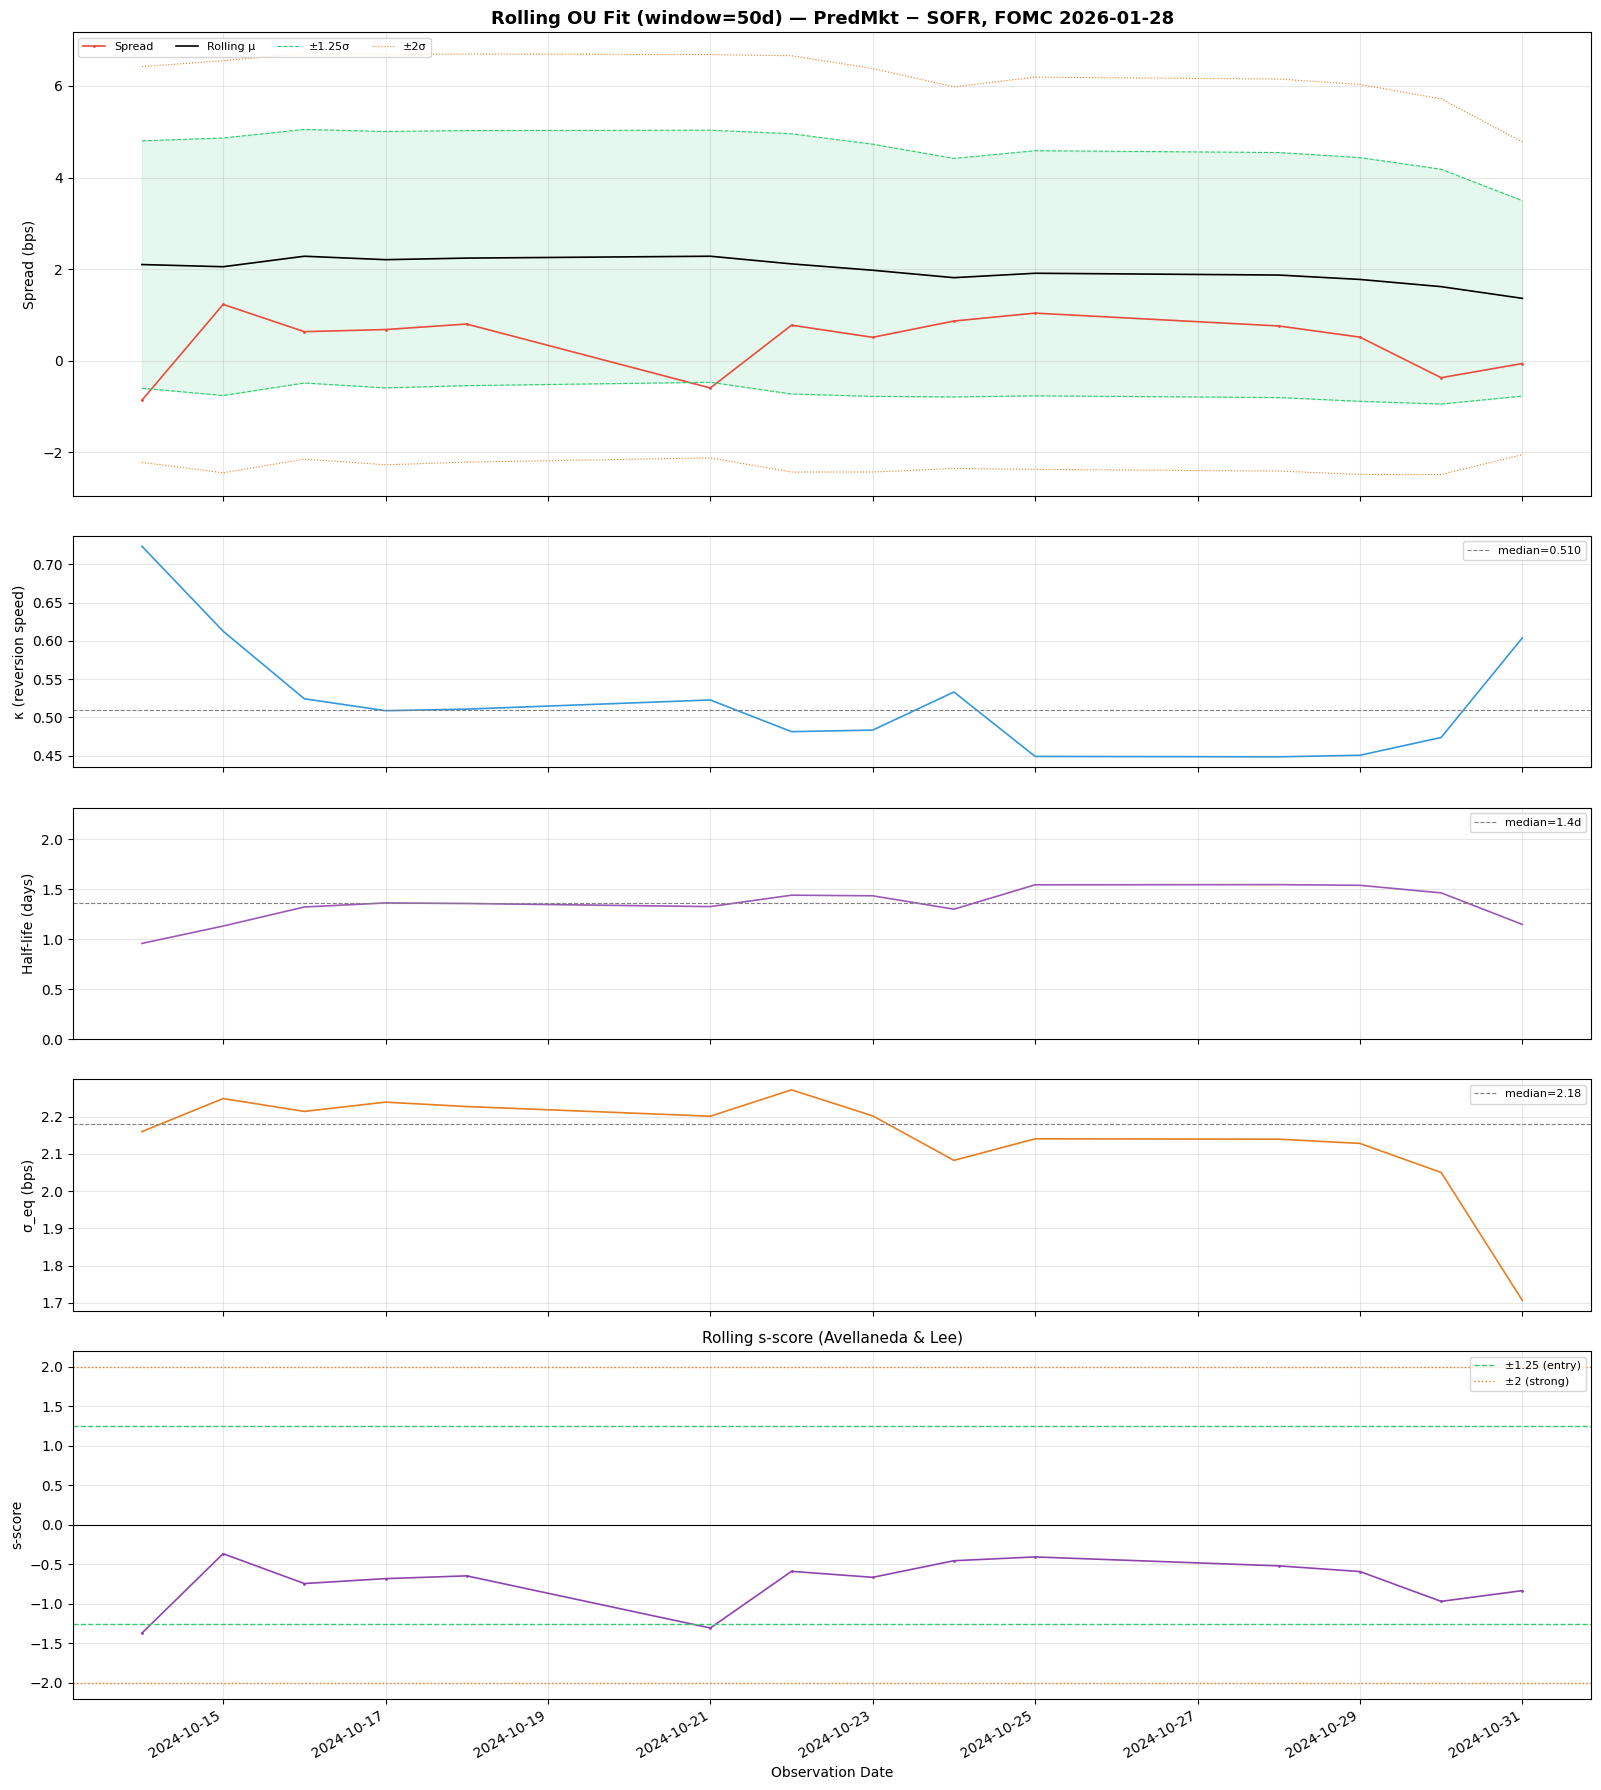

In [47]:
fig, axes = plt.subplots(5, 1, figsize=(16, 18), sharex=True,
                         gridspec_kw={"height_ratios": [2, 1, 1, 1, 1.5]})

# 1) Spread with rolling mu and bands
ax = axes[0]
ax.plot(rolling.index, rolling["spread"], color="#e74c3c", linewidth=1.2,
        marker=".", markersize=2, label="Spread")
ax.plot(rolling.index, rolling["mu"], color="black", linewidth=1.2, label="Rolling μ")
upper_entry = rolling["mu"] + 1.25 * rolling["sigma_eq"]
lower_entry = rolling["mu"] - 1.25 * rolling["sigma_eq"]
upper_strong = rolling["mu"] + 2 * rolling["sigma_eq"]
lower_strong = rolling["mu"] - 2 * rolling["sigma_eq"]
ax.fill_between(rolling.index, lower_entry, upper_entry, alpha=0.12, color="#2ecc71")
ax.plot(rolling.index, upper_entry, color="#2ecc71", linewidth=0.8, linestyle="--", label="±1.25σ")
ax.plot(rolling.index, lower_entry, color="#2ecc71", linewidth=0.8, linestyle="--")
ax.plot(rolling.index, upper_strong, color="#e67e22", linewidth=0.8, linestyle=":", label="±2σ")
ax.plot(rolling.index, lower_strong, color="#e67e22", linewidth=0.8, linestyle=":")
ax.set_ylabel("Spread (bps)")
ax.set_title(f"Rolling OU Fit (window={WINDOW}d) — PredMkt − SOFR, FOMC 2026-01-28",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=8, ncol=5, loc="upper left")
ax.grid(True, alpha=0.3)

# 2) Rolling kappa
ax = axes[1]
ax.plot(rolling.index, rolling["kappa"], color="#3498db", linewidth=1.2)
ax.set_ylabel("κ (reversion speed)")
ax.axhline(rolling["kappa"].median(), color="gray", linestyle="--", linewidth=0.8,
           label=f'median={rolling["kappa"].median():.3f}')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# 3) Rolling half-life
ax = axes[2]
ax.plot(rolling.index, rolling["halflife"], color="#9b59b6", linewidth=1.2)
ax.set_ylabel("Half-life (days)")
ax.set_ylim(0, min(rolling["halflife"].quantile(0.95) * 1.5, 60))
ax.axhline(rolling["halflife"].median(), color="gray", linestyle="--", linewidth=0.8,
           label=f'median={rolling["halflife"].median():.1f}d')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# 4) Rolling sigma_eq
ax = axes[3]
ax.plot(rolling.index, rolling["sigma_eq"], color="#e67e22", linewidth=1.2)
ax.set_ylabel("σ_eq (bps)")
ax.axhline(rolling["sigma_eq"].median(), color="gray", linestyle="--", linewidth=0.8,
           label=f'median={rolling["sigma_eq"].median():.2f}')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# 5) Rolling s-score with thresholds
ax = axes[4]
ax.plot(rolling.index, rolling["s_score"], color="#8e44ad", linewidth=1.2,
        marker=".", markersize=2)
ax.axhline(0, color="black", linewidth=0.8)
ax.axhline(1.25, color="#2ecc71", linestyle="--", linewidth=1, label="±1.25 (entry)")
ax.axhline(-1.25, color="#2ecc71", linestyle="--", linewidth=1)
ax.axhline(2, color="#e67e22", linestyle=":", linewidth=1, label="±2 (strong)")
ax.axhline(-2, color="#e67e22", linestyle=":", linewidth=1)
ax.set_ylabel("s-score")
ax.set_xlabel("Observation Date")
ax.set_title("Rolling s-score (Avellaneda & Lee)", fontsize=11)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

Total signals:  1
  Buy  (long spread):  1
  Sell (short spread): 0


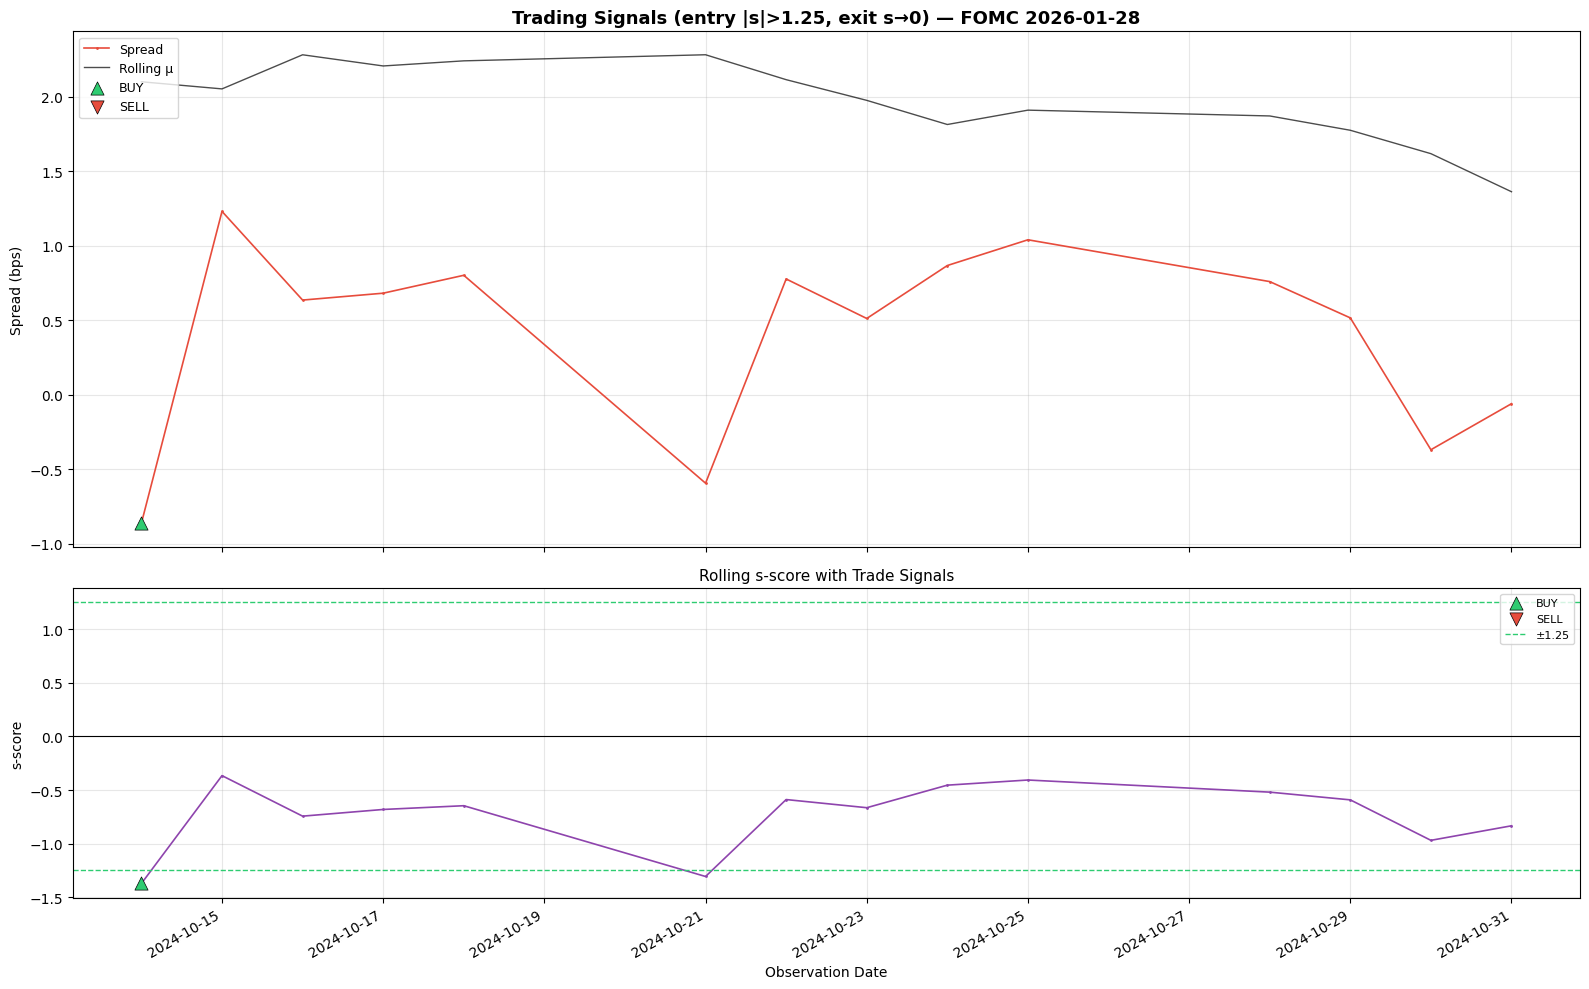

In [48]:
# --- Generate trading signals from rolling s-score ---

ENTRY = 1.25
EXIT = 0.0

s = rolling["s_score"].values
signals = np.zeros(len(s), dtype=int)
position = 0

for i in range(len(s)):
    if np.isnan(s[i]):
        signals[i] = 0
        continue

    if position == 0:
        if s[i] < -ENTRY:
            position = 1
            signals[i] = 1
        elif s[i] > ENTRY:
            position = -1
            signals[i] = -1
    elif position == 1:
        if s[i] >= EXIT:
            position = 0
            signals[i] = 0
        elif s[i] > ENTRY:
            position = -1
            signals[i] = -1
        else:
            signals[i] = 0
    elif position == -1:
        if s[i] <= -EXIT:
            position = 0
            signals[i] = 0
        elif s[i] < -ENTRY:
            position = 1
            signals[i] = 1
        else:
            signals[i] = 0

rolling["signal"] = signals

buys  = rolling[rolling["signal"] == 1]
sells = rolling[rolling["signal"] == -1]

print(f"Total signals:  {(signals != 0).sum()}")
print(f"  Buy  (long spread):  {len(buys)}")
print(f"  Sell (short spread): {len(sells)}")

# --- Plot: spread + s-score with trade markers ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10), sharex=True,
                                gridspec_kw={"height_ratios": [2, 1.2]})

ax1.plot(rolling.index, rolling["spread"], color="#e74c3c", linewidth=1.2,
         marker=".", markersize=2, label="Spread")
ax1.plot(rolling.index, rolling["mu"], color="black", linewidth=1, alpha=0.7, label="Rolling μ")
ax1.scatter(buys.index, buys["spread"], marker="^", s=90, color="#2ecc71",
            edgecolors="black", linewidths=0.5, zorder=5, label="BUY")
ax1.scatter(sells.index, sells["spread"], marker="v", s=90, color="#e74c3c",
            edgecolors="black", linewidths=0.5, zorder=5, label="SELL")
ax1.set_ylabel("Spread (bps)")
ax1.set_title(f"Trading Signals (entry |s|>{ENTRY}, exit s→0) — FOMC 2026-01-28",
              fontsize=13, fontweight="bold")
ax1.legend(fontsize=9, loc="upper left")
ax1.grid(True, alpha=0.3)

ax2.plot(rolling.index, rolling["s_score"], color="#8e44ad", linewidth=1.2,
         marker=".", markersize=2)
ax2.scatter(buys.index, buys["s_score"], marker="^", s=90, color="#2ecc71",
            edgecolors="black", linewidths=0.5, zorder=5, label="BUY")
ax2.scatter(sells.index, sells["s_score"], marker="v", s=90, color="#e74c3c",
            edgecolors="black", linewidths=0.5, zorder=5, label="SELL")
ax2.axhline(0, color="black", linewidth=0.8)
ax2.axhline(ENTRY, color="#2ecc71", linestyle="--", linewidth=1, label=f"±{ENTRY}")
ax2.axhline(-ENTRY, color="#2ecc71", linestyle="--", linewidth=1)
ax2.set_ylabel("s-score")
ax2.set_xlabel("Observation Date")
ax2.set_title("Rolling s-score with Trade Signals", fontsize=11)
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

  BACKTEST RESULTS (PredMkt vs EFFR)
  Total PnL:         0.80 bps
  # Trades:          0
  Win / Loss:        0 / 0  (0% win rate)
  Avg Winner:        +0.00 bps
  Avg Loser:         +0.00 bps
  Avg Duration:      0.0 days
  Max Drawdown:      -1.82 bps
  Sharpe (ann.):     1.09
  % Time in Market:  100.0%


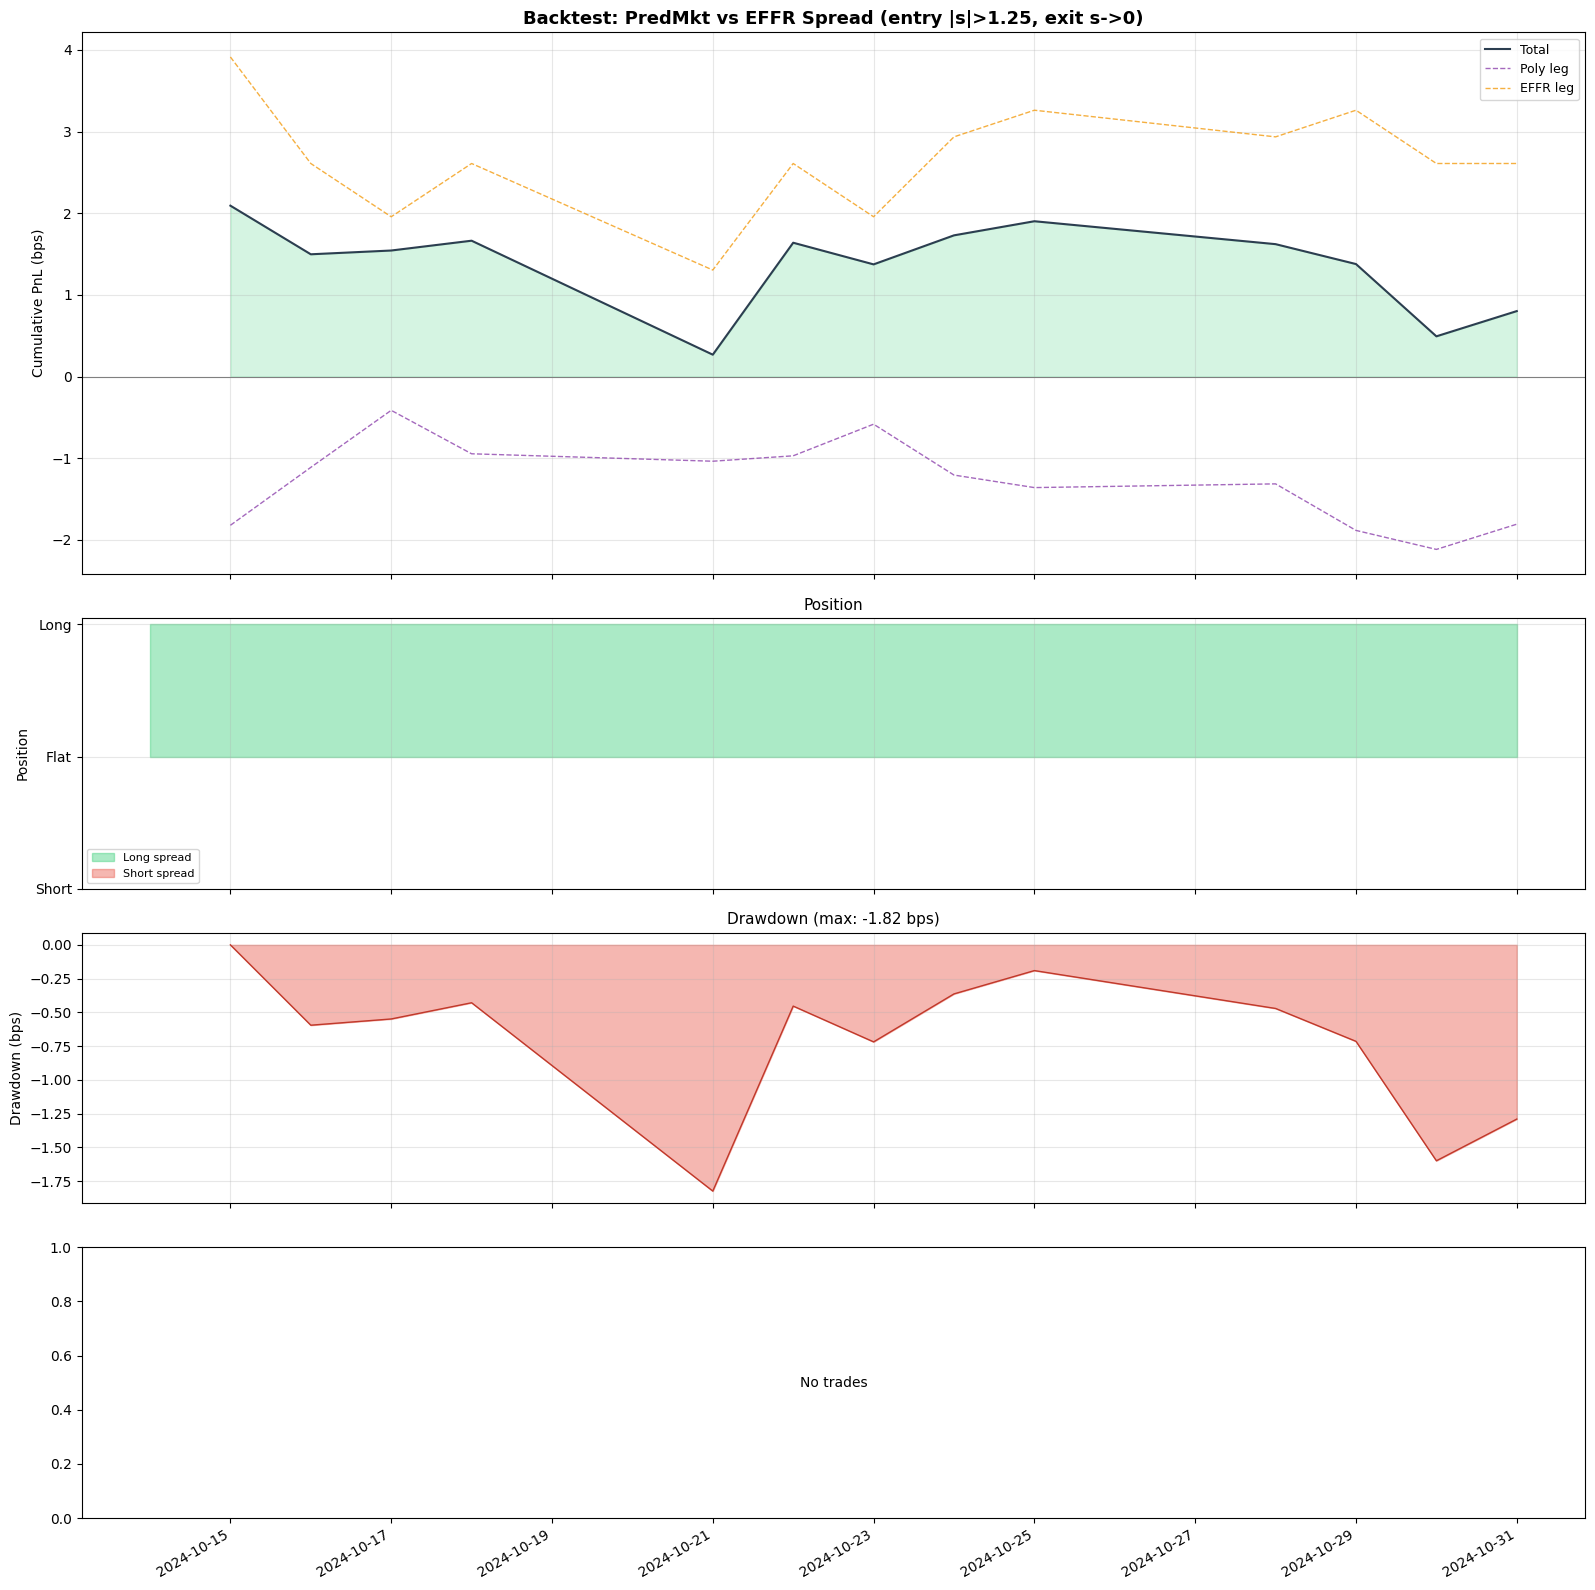

In [49]:
# --- Backtest: trade polymarket vs EFFR legs on s-score signals ---

legs = mdf_clean.set_index("observed_day_pst")[["predmkt_avg_bps", "effr_expected_bps"]].copy()
bt = rolling[["spread", "s_score", "signal", "mu", "sigma_eq"]].join(legs, how="left")

pos = np.zeros(len(bt))
p = 0
for i in range(len(bt)):
    sig = bt["signal"].iloc[i]
    if sig == 1:
        p = 1
    elif sig == -1:
        p = -1
    s_val = bt["s_score"].iloc[i]
    if p == 1 and not np.isnan(s_val) and s_val >= 0:
        p = 0
    elif p == -1 and not np.isnan(s_val) and s_val <= 0:
        p = 0
    pos[i] = p

bt["position"] = pos

bt["d_poly"] = bt["predmkt_avg_bps"].diff()
bt["d_effr"] = bt["effr_expected_bps"].diff()
bt["d_spread"] = bt["spread"].diff()

bt["pnl_poly"] = bt["position"].shift(1) * bt["d_poly"]
bt["pnl_effr"] = -bt["position"].shift(1) * bt["d_effr"]
bt["pnl_total"] = bt["position"].shift(1) * bt["d_spread"]

bt["cum_pnl_poly"] = bt["pnl_poly"].cumsum()
bt["cum_pnl_effr"] = bt["pnl_effr"].cumsum()
bt["cum_pnl"] = bt["pnl_total"].cumsum()

bt["peak"] = bt["cum_pnl"].cummax()
bt["drawdown"] = bt["cum_pnl"] - bt["peak"]

trades = []
entry_date = None
entry_spread = None
trade_dir = 0
for i in range(1, len(bt)):
    prev_pos = bt["position"].iloc[i - 1]
    curr_pos = bt["position"].iloc[i]
    if prev_pos == 0 and curr_pos != 0:
        entry_date = bt.index[i]
        entry_spread = bt["spread"].iloc[i]
        trade_dir = int(curr_pos)
    elif prev_pos != 0 and curr_pos == 0 and entry_date is not None:
        exit_spread = bt["spread"].iloc[i]
        pnl = trade_dir * (exit_spread - entry_spread)
        trades.append({
            "entry": entry_date, "exit": bt.index[i],
            "direction": "LONG" if trade_dir == 1 else "SHORT",
            "entry_spread": entry_spread, "exit_spread": exit_spread,
            "pnl_bps": pnl, "duration": (bt.index[i] - entry_date).days,
        })
        entry_date = None
    elif prev_pos != 0 and curr_pos != 0 and curr_pos != prev_pos and entry_date is not None:
        exit_spread = bt["spread"].iloc[i]
        pnl = trade_dir * (exit_spread - entry_spread)
        trades.append({
            "entry": entry_date, "exit": bt.index[i],
            "direction": "LONG" if trade_dir == 1 else "SHORT",
            "entry_spread": entry_spread, "exit_spread": exit_spread,
            "pnl_bps": pnl, "duration": (bt.index[i] - entry_date).days,
        })
        entry_date = bt.index[i]
        entry_spread = bt["spread"].iloc[i]
        trade_dir = int(curr_pos)

trades_df = pd.DataFrame(trades)

total_pnl = bt["cum_pnl"].iloc[-1]
n_trades = len(trades_df)
winners = (trades_df["pnl_bps"] > 0).sum() if n_trades > 0 else 0
losers = (trades_df["pnl_bps"] <= 0).sum() if n_trades > 0 else 0
win_rate = winners / n_trades * 100 if n_trades > 0 else 0
avg_win = trades_df.loc[trades_df["pnl_bps"] > 0, "pnl_bps"].mean() if winners > 0 else 0
avg_loss = trades_df.loc[trades_df["pnl_bps"] <= 0, "pnl_bps"].mean() if losers > 0 else 0
max_dd = bt["drawdown"].min()
daily_ret = bt["pnl_total"].dropna()
sharpe = daily_ret.mean() / daily_ret.std() * np.sqrt(252) if daily_ret.std() > 0 else np.nan
avg_duration = trades_df["duration"].mean() if n_trades > 0 else 0
pct_in_market = (bt["position"] != 0).mean() * 100

print("=" * 60)
print("  BACKTEST RESULTS (PredMkt vs EFFR)")
print("=" * 60)
print(f"  Total PnL:         {total_pnl:.2f} bps")
print(f"  # Trades:          {n_trades}")
print(f"  Win / Loss:        {winners} / {losers}  ({win_rate:.0f}% win rate)")
print(f"  Avg Winner:        {avg_win:+.2f} bps")
print(f"  Avg Loser:         {avg_loss:+.2f} bps")
print(f"  Avg Duration:      {avg_duration:.1f} days")
print(f"  Max Drawdown:      {max_dd:.2f} bps")
print(f"  Sharpe (ann.):     {sharpe:.2f}")
print(f"  % Time in Market:  {pct_in_market:.1f}%")
print("=" * 60)

if n_trades > 0:
    print("\n  Trade Log:")
    for _, t in trades_df.iterrows():
        print(f"    {t['direction']:5s}  {str(t['entry'].date()):>10s} -> {str(t['exit'].date()):>10s}"
              f"  ({t['duration']:3d}d)  PnL: {t['pnl_bps']:+.2f} bps")

fig, axes = plt.subplots(4, 1, figsize=(16, 16), sharex=True,
                         gridspec_kw={"height_ratios": [2, 1, 1, 1]})

ax = axes[0]
ax.fill_between(bt.index, 0, bt["cum_pnl"], alpha=0.2,
                color="#2ecc71" if total_pnl >= 0 else "#e74c3c")
ax.plot(bt.index, bt["cum_pnl"], color="#2c3e50", linewidth=1.5, label="Total")
ax.plot(bt.index, bt["cum_pnl_poly"], color="#8e44ad", linewidth=1, alpha=0.8,
        linestyle="--", label="Poly leg")
ax.plot(bt.index, bt["cum_pnl_effr"], color="#f39c12", linewidth=1, alpha=0.8,
        linestyle="--", label="EFFR leg")
ax.axhline(0, color="gray", linewidth=0.8)
ax.set_ylabel("Cumulative PnL (bps)")
ax.set_title(f"Backtest: PredMkt vs EFFR Spread (entry |s|>{ENTRY}, exit s->0)",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.fill_between(bt.index, 0, bt["position"], step="post", alpha=0.4,
                where=bt["position"] > 0, color="#2ecc71", label="Long spread")
ax.fill_between(bt.index, 0, bt["position"], step="post", alpha=0.4,
                where=bt["position"] < 0, color="#e74c3c", label="Short spread")
ax.set_ylabel("Position")
ax.set_yticks([-1, 0, 1])
ax.set_yticklabels(["Short", "Flat", "Long"])
ax.set_title("Position", fontsize=11)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

ax = axes[2]
ax.fill_between(bt.index, bt["drawdown"], 0, color="#e74c3c", alpha=0.4)
ax.plot(bt.index, bt["drawdown"], color="#c0392b", linewidth=1)
ax.set_ylabel("Drawdown (bps)")
ax.set_title(f"Drawdown (max: {max_dd:.2f} bps)", fontsize=11)
ax.grid(True, alpha=0.3)

ax = axes[3]
if n_trades > 0:
    colors = ["#2ecc71" if p > 0 else "#e74c3c" for p in trades_df["pnl_bps"]]
    ax.bar(range(n_trades), trades_df["pnl_bps"], color=colors, edgecolor="black", linewidth=0.5)
    ax.axhline(0, color="gray", linewidth=0.8)
    ax.set_ylabel("PnL (bps)")
    ax.set_xlabel("Trade #")
    ax.set_title(f"Per-Trade PnL ({winners}W / {losers}L, {win_rate:.0f}% win rate)", fontsize=11)
    ax.grid(True, alpha=0.3, axis="y")
else:
    ax.text(0.5, 0.5, "No trades", ha="center", va="center", transform=ax.transAxes)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()